# Temporal patterns — sazonalidade, autocorrelação, estacionariedade

Para decidir o modelo a usar, precisas saber:

- **Memória**: ACF/PACF — quanto tempo o passado "lembra"?
- **Sazonalidade**: weekly (dias de release Valve), monthly, yearly?
- **Estacionariedade**: o preço cresce ou oscila? (ADF test)
- **Decomposição**: trend + seasonal + residual — quanto da variância é cada um?

Estes diagnósticos determinam se um AR/ARIMA chega ou se precisas de modelos mais sofisticados.

In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import STL

PARQUET = "../data/items.parquet"
pl.Config.set_tbl_rows(10)

polars.config.Config

In [2]:
import sys; sys.path.insert(0, ".")
from _helpers import get_daily, list_top_items

## 1. Pick representative items

In [ ]:
top = list_top_items(n=30, min_history_days=365 * 5 * 24)
print(top.head(10))

# Picks: high-liquidity rifle, knife, low-tier
SAMPLES = [
    "AK-47 | Redline (Field-Tested)",
    "AWP | Asiimov (Field-Tested)",
    "★ Karambit | Doppler (Factory New)",
    "Glock-18 | Water Elemental (Field-Tested)",
]
for s in SAMPLES:
    df = get_daily(s)
    print(f"{s:55} {df.height:5} days  {df['date'].min()} → {df['date'].max()}")

## 2. Long-term price + moving averages

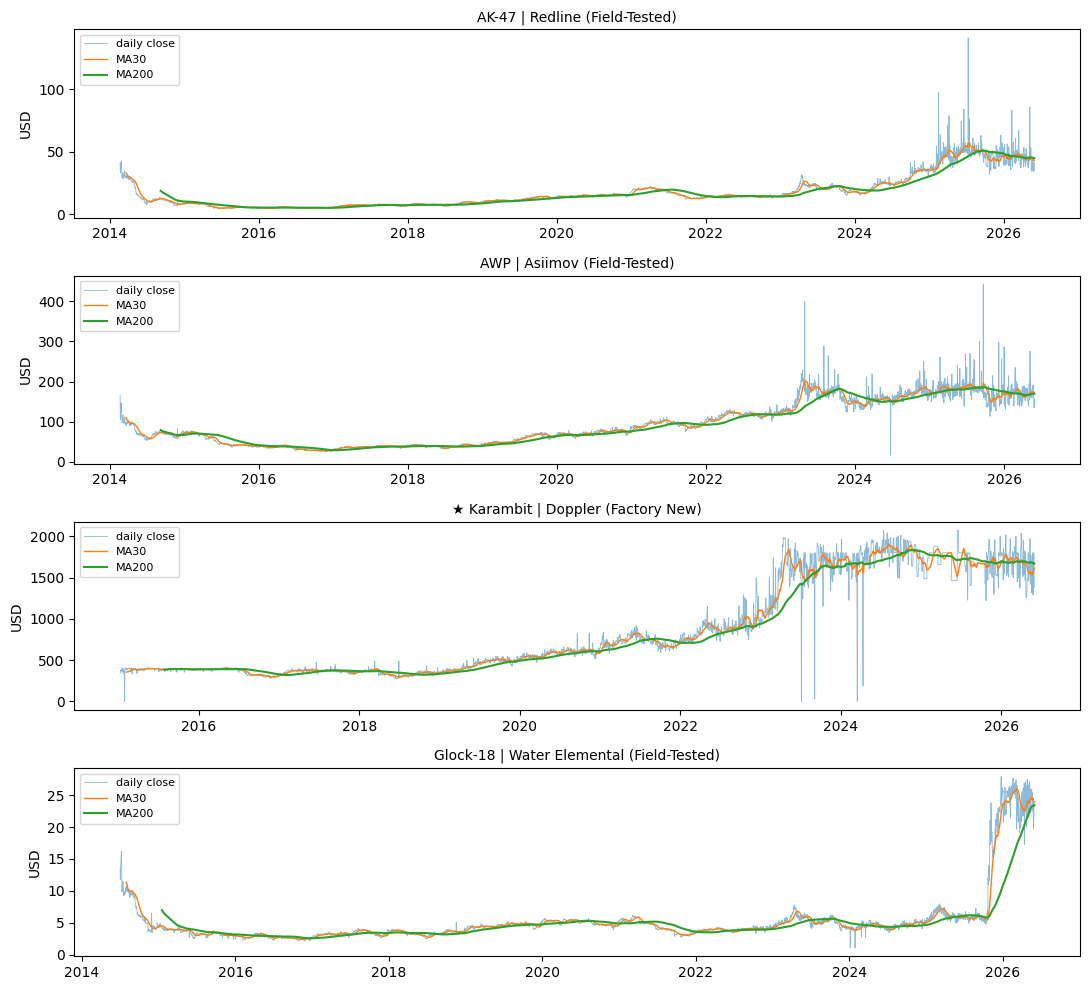

In [ ]:
fig, axes = plt.subplots(len(SAMPLES), 1, figsize=(11, 10), sharex=False)
for ax, name in zip(axes, SAMPLES):
    df = get_daily(name).with_columns([
        pl.col("price").rolling_mean(30).alias("ma30"),
        pl.col("price").rolling_mean(200).alias("ma200"),
    ])
    ax.plot(df["date"], df["price"], lw=0.6, alpha=0.5, label="daily close")
    ax.plot(df["date"], df["ma30"], lw=1, label="MA30")
    ax.plot(df["date"], df["ma200"], lw=1.5, label="MA200")
    ax.set_title(name, fontsize=10)
    ax.legend(loc="upper left", fontsize=8)
    ax.set_ylabel("USD")
plt.tight_layout()
plt.show()

## 3. STL decomposition

Separamos `trend + seasonal_yearly + residual`. Se a variância do seasonal for grande relativa ao trend → vale a pena modelar sazonalidade.

In [ ]:
def stl_summary(name, period=365):
    df = get_daily(name).filter(pl.col("price") > 0)
    if df.height < 3 * period:
        return None
    s = df["price"].to_numpy()
    stl = STL(s, period=period, robust=True).fit()
    var_total = np.var(s)
    return {
        "name": name,
        "trend_var_share": np.var(stl.trend) / var_total,
        "seasonal_var_share": np.var(stl.seasonal) / var_total,
        "resid_var_share": np.var(stl.resid) / var_total,
    }

rows = [stl_summary(n) for n in SAMPLES]
print(pl.DataFrame([r for r in rows if r]))

shape: (4, 4)
┌─────────────────────────────────┬─────────────────┬────────────────────┬─────────────────┐
│ name                            ┆ trend_var_share ┆ seasonal_var_share ┆ resid_var_share │
│ ---                             ┆ ---             ┆ ---                ┆ ---             │
│ str                             ┆ f64             ┆ f64                ┆ f64             │
╞═════════════════════════════════╪═════════════════╪════════════════════╪═════════════════╡
│ AK-47 | Redline (Field-Tested)  ┆ 0.783287        ┆ 0.052264           ┆ 0.134808        │
│ AWP | Asiimov (Field-Tested)    ┆ 0.828755        ┆ 0.021686           ┆ 0.067695        │
│ ★ Karambit | Doppler (Factory … ┆ 0.87198         ┆ 0.023586           ┆ 0.071351        │
│ Glock-18 | Water Elemental (Fi… ┆ 0.863932        ┆ 0.063178           ┆ 0.287697        │
└─────────────────────────────────┴─────────────────┴────────────────────┴─────────────────┘


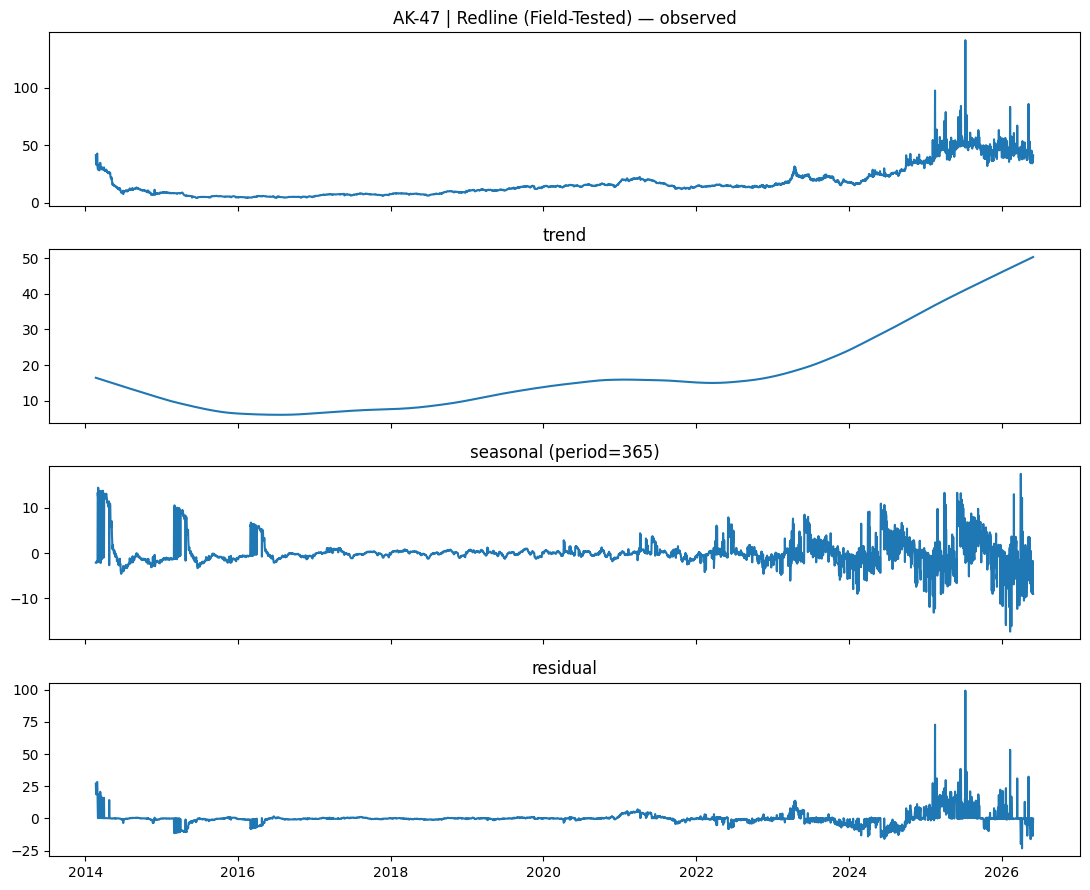

In [ ]:
# Visual decomposition for one item
df = get_daily(SAMPLES[0]).filter(pl.col("price") > 0)
s = df["price"].to_numpy()
stl = STL(s, period=365, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
axes[0].plot(df["date"], s); axes[0].set_title(f"{SAMPLES[0]} — observed")
axes[1].plot(df["date"], stl.trend); axes[1].set_title("trend")
axes[2].plot(df["date"], stl.seasonal); axes[2].set_title("seasonal (period=365)")
axes[3].plot(df["date"], stl.resid); axes[3].set_title("residual")
plt.tight_layout(); plt.show()

## 4. ACF & PACF — qual a memória?

- **Prices**: tipicamente quase 1 em todos os lags → não-estacionário.
- **Log-returns**: o teste real. Onde a ACF passa abaixo da banda? Esse é o lag útil máximo.

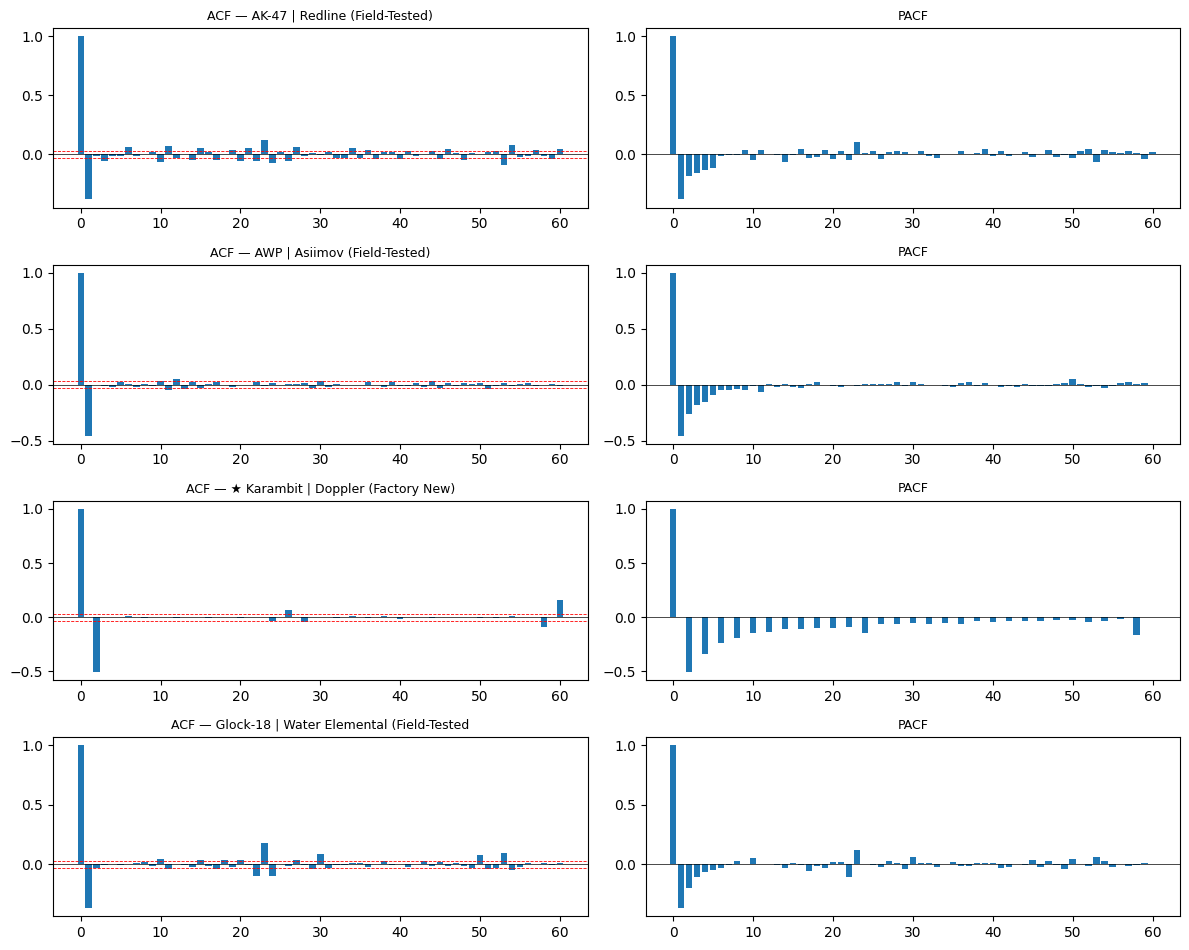

In [ ]:
def log_returns(df):
    p = df["price"].to_numpy()
    return np.diff(np.log(np.clip(p, 1e-6, None)))

fig, axes = plt.subplots(len(SAMPLES), 2, figsize=(12, 2.4*len(SAMPLES)))
for i, name in enumerate(SAMPLES):
    df = get_daily(name).filter(pl.col("price") > 0)
    r = log_returns(df)
    a, ci_a = acf(r, nlags=60, alpha=0.05)
    p, ci_p = pacf(r, nlags=60, alpha=0.05)
    axes[i,0].bar(range(len(a)), a); axes[i,0].axhline(0, color="k", lw=0.5)
    axes[i,0].axhline(ci_a[1,1]-a[1], color="r", ls="--", lw=0.6)
    axes[i,0].axhline(-(ci_a[1,1]-a[1]), color="r", ls="--", lw=0.6)
    axes[i,0].set_title(f"ACF — {name[:40]}", fontsize=9)
    axes[i,1].bar(range(len(p)), p); axes[i,1].axhline(0, color="k", lw=0.5)
    axes[i,1].set_title("PACF", fontsize=9)
plt.tight_layout(); plt.show()

## 5. Weekly seasonality — dia da semana

In [ ]:
rows = []
for name in SAMPLES:
    df = get_daily(name).filter(pl.col("price") > 0)
    r = log_returns(df)
    # Align dow: returns at index i correspond to df.date[i+1]
    dow = df["date"][1:].dt.weekday().to_numpy()
    for d in range(7):
        mask = dow == d
        if mask.sum() > 30:
            rows.append({"item": name[:30], "dow": d, "mean_return_bps": float(r[mask].mean()*1e4), "n": int(mask.sum())})
dow_tbl = pl.DataFrame(rows)
print(dow_tbl.pivot(index="dow", on="item", values="mean_return_bps"))
print("\n(0=Mon, 6=Sun. Valores em bps de log-return médio por dia da semana.)")

shape: (6, 5)
┌─────┬─────────────────┬────────────────┬────────────────────────┬────────────────────────────────┐
│ dow ┆ AK-47 | Redline ┆ AWP | Asiimov  ┆ ★ Karambit | Doppler   ┆ Glock-18 | Water Elemental (Fi │
│ --- ┆ (Field-Tested)  ┆ (Field-Tested) ┆ (Factory               ┆ ---                            │
│ i64 ┆ ---             ┆ ---            ┆ ---                    ┆ f64                            │
│     ┆ f64             ┆ f64            ┆ f64                    ┆                                │
╞═════╪═════════════════╪════════════════╪════════════════════════╪════════════════════════════════╡
│ 1   ┆ 23.536439       ┆ -65.202063     ┆ 55.130577              ┆ -1.423389                      │
│ 2   ┆ 37.615213       ┆ 78.215472      ┆ 5.717487               ┆ 49.682235                      │
│ 3   ┆ -15.640105      ┆ -23.14861      ┆ 44.604039              ┆ -11.844973                     │
│ 4   ┆ -24.286685      ┆ 13.407505      ┆ -338.465154            ┆ -13.85275

## 6. Stationarity (ADF test) — preço vs log-return

In [ ]:
rows = []
for name in SAMPLES:
    df = get_daily(name).filter(pl.col("price") > 0)
    p = df["price"].to_numpy()
    r = log_returns(df)
    adf_p = adfuller(p, autolag="AIC")[1]
    adf_r = adfuller(r, autolag="AIC")[1]
    rows.append({"item": name[:40], "adf_pval_price": adf_p, "adf_pval_logret": adf_r})
print(pl.DataFrame(rows))
print("\np-value < 0.05 → estacionário. Esperar preços não-estacionários, returns estacionários.")

shape: (4, 3)
┌─────────────────────────────────┬────────────────┬─────────────────┐
│ item                            ┆ adf_pval_price ┆ adf_pval_logret │
│ ---                             ┆ ---            ┆ ---             │
│ str                             ┆ f64            ┆ f64             │
╞═════════════════════════════════╪════════════════╪═════════════════╡
│ AK-47 | Redline (Field-Tested)  ┆ 0.799636       ┆ 3.1487e-21      │
│ AWP | Asiimov (Field-Tested)    ┆ 0.843761       ┆ 0.0             │
│ ★ Karambit | Doppler (Factory … ┆ 0.863909       ┆ 0.0             │
│ Glock-18 | Water Elemental (Fi… ┆ 0.977024       ┆ 5.2542e-23      │
└─────────────────────────────────┴────────────────┴─────────────────┘

p-value < 0.05 → estacionário. Esperar preços não-estacionários, returns estacionários.


## Conclusões

Olha as três coisas acima e escreve aqui:
- Preço é não-estacionário em ~todos? → modelar **log-returns**, não preços.
- ACF dos returns extingue antes do lag 7? → memória curta, AR(7) chega.
- Sazonalidade weekly significativa? → adiciona dummies dow ou usa SARIMA.
- Sazonalidade yearly grande (STL)? → operations/events anuais importam.